In [147]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from dowhy import CausalModel
from sklearn.preprocessing import RobustScaler
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import graphviz
from IPython.display import display


In [ ]:
df = pd.read_csv("alerts_with_category_with_apk_size_updated.csv")
print("Original rows:", len(df))

df = df[~df["code_location"].str.contains("obfuscated", case=False, na=False)].copy()
print("After removing obfuscated:", len(df))

df["verdict"] = df["verdict"].astype(int)
df["is_third_party"] = (~df["code_location"].isin(["developer_written"])).astype(int)
print(df["is_third_party"].value_counts())
df["lib_category"] = df["code_location"].apply(
    lambda x: x if x != "developer_written" else "source"
)

df["developer_written_and_third_party"] = (
    (df["code_location"] == "developer_written") | (df["is_third_party"] == 1)
).astype(int)


df_all = df.copy()
df_all["combined"] = 1
df_developer_written = df[df["code_location"] == "developer_written"].copy()
df_developer_written["combined"] = 0
df_final = pd.concat([df_all, df_developer_written], ignore_index=True)



print("\nVerdict value counts:")
print(df["verdict"].value_counts())
print("\nCode location value counts:")
print(df["code_location"].value_counts())


Original rows: 6140
After removing obfuscated: 5612
is_third_party
1    5101
0     511
Name: count, dtype: int64

Verdict value counts:
verdict
0    2898
1    2714
Name: count, dtype: int64

Code location value counts:
code_location
Utilities            3039
others               1341
developer_written     511
Android               494
SocialMedia           180
Analytics              34
Cloud                  13
Name: count, dtype: int64


In [128]:
len(df_final)

In [129]:
df.columns

Index(['alert_description', 'verdict', 'artifact_location', 'app_package_name',
       'version_code', 'app_popularity', 'sast_tool_name', 'code_location',
       '3rd_party_library_name', 'apk_size', 'is_third_party', 'lib_category',
       'developer_written_and_third_party'],
      dtype='object')

In [130]:
df_final["combined"].value_counts()

combined
1    5612
0     511
Name: count, dtype: int64

In [131]:
df = df_final.copy()

In [132]:
scaler = RobustScaler()
df["apk_size_scaled"] = scaler.fit_transform(df[["apk_size"]])
print("\napk_size_scaled summary:")
print(df["apk_size_scaled"].describe())



apk_size_scaled summary:
count    6123.000000
mean        0.476091
std         1.427522
min        -0.722947
25%        -0.341066
50%         0.000000
75%         0.658934
max         9.163311
Name: apk_size_scaled, dtype: float64


In [133]:
category_order = [
    '<100','100-500','500-1k','1k-5k','5k-10k','10k-50k',
    '50k-100k','100k-500k','500k-1M','1M-5M','>5M'
]
ord_map = {c: i for i, c in enumerate(category_order)}

df["app_popularity_encoded"] = df["app_popularity"].map(ord_map)

df = df.dropna(subset=["app_popularity_encoded"]).copy()
df["app_popularity_encoded"] = df["app_popularity_encoded"].astype(int)

print("\nApp popularity encoded value counts:")
print(df["app_popularity_encoded"].value_counts().sort_index())




App popularity encoded value counts:
app_popularity_encoded
0     706
1     633
2     368
3     368
4     450
5     487
6     477
7     757
8     658
9     662
10    557
Name: count, dtype: int64


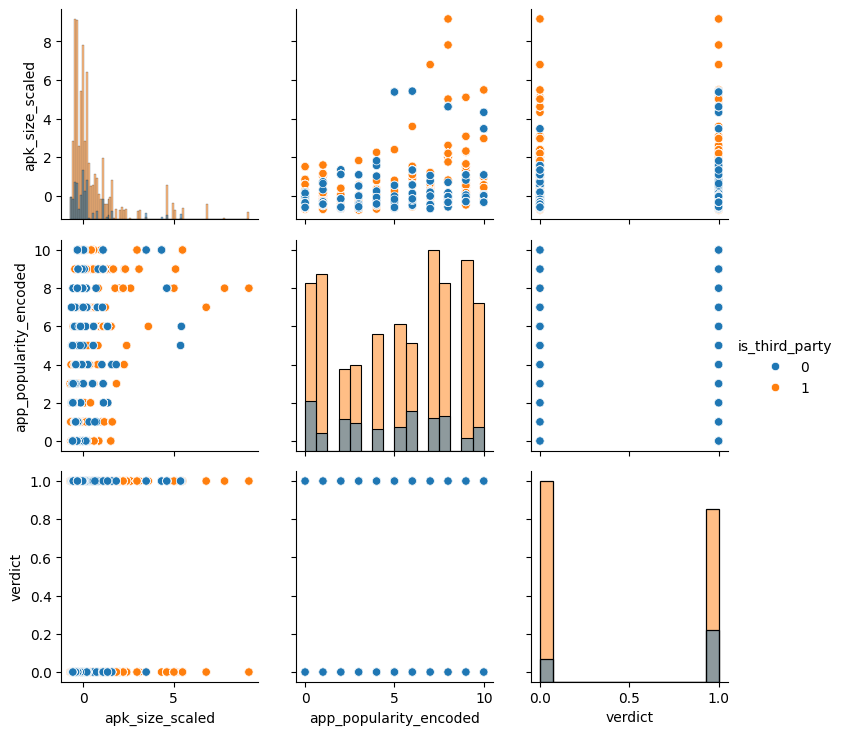

In [134]:
cols = ["apk_size_scaled", "app_popularity_encoded", "verdict", "is_third_party"]

g = sns.PairGrid(df[cols], hue="is_third_party", diag_sharey=False)
g.map_diag(sns.histplot)
g.map_offdiag(sns.scatterplot)
g.add_legend()
plt.show()

In [135]:
n_bootstraps = 200
boot_means = {
    "apk_size_scaled": [],
    "verdict": [],
    "is_third_party": [],
}

for _ in range(n_bootstraps):
    boot_sample = df.sample(frac=1, replace=True)
    boot_means["apk_size_scaled"].append(boot_sample["apk_size_scaled"].mean())
    boot_means["verdict"].append(boot_sample["verdict"].mean())
    boot_means["is_third_party"].append(boot_sample["is_third_party"].mean())

summary = {}
for col, values in boot_means.items():
    values = np.array(values)
    summary[col] = {
        "mean": np.mean(values),
        "std": np.std(values, ddof=1),
        "95% CI lower": np.percentile(values, 2.5),
        "95% CI upper": np.percentile(values, 97.5),
    }

summary_df = pd.DataFrame(summary).T
print("\nBootstrap summary (descriptive stats):")
print(summary_df)




Bootstrap summary (descriptive stats):
                     mean       std  95% CI lower  95% CI upper
apk_size_scaled  0.476321  0.017903      0.445718      0.509469
verdict          0.501109  0.005916      0.490111      0.512502
is_third_party   0.833182  0.004698      0.824102      0.842406


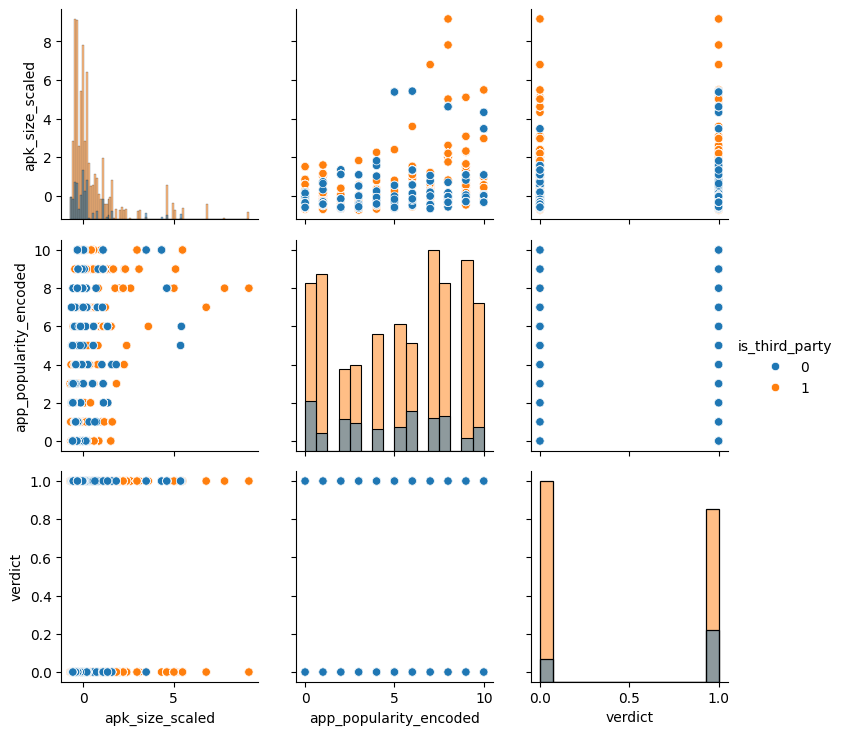

In [136]:
cols = ["apk_size_scaled", "app_popularity_encoded", "verdict", "is_third_party"]

g = sns.PairGrid(df[cols], hue="is_third_party", diag_sharey=False)
g.map_diag(sns.histplot)
g.map_offdiag(sns.scatterplot)
g.add_legend()
plt.show()

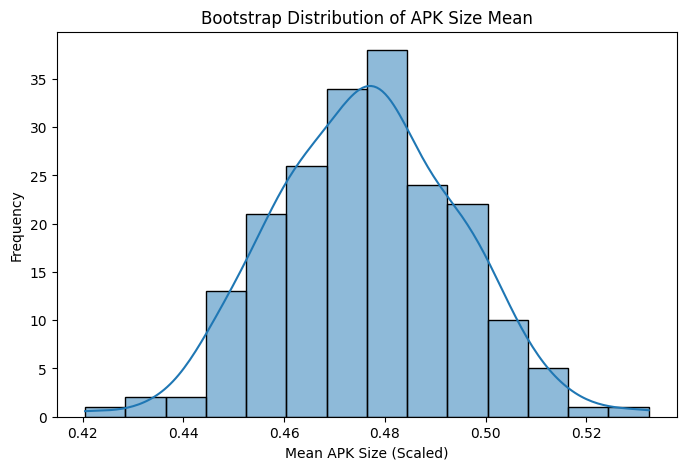

In [137]:
plt.figure(figsize=(8,5))
sns.histplot(boot_means["apk_size_scaled"], kde=True)
plt.title("Bootstrap Distribution of APK Size Mean")
plt.xlabel("Mean APK Size (Scaled)")
plt.ylabel("Frequency")
plt.show()

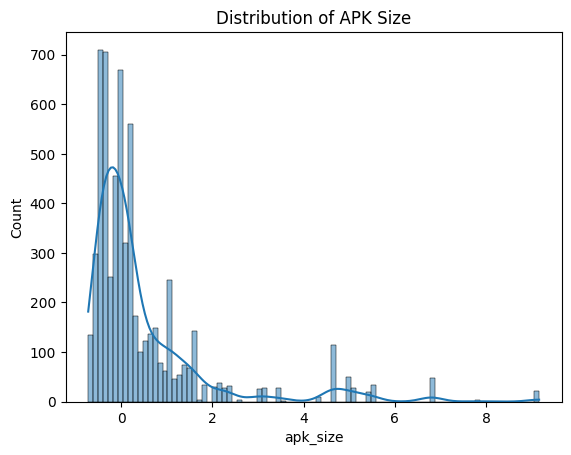

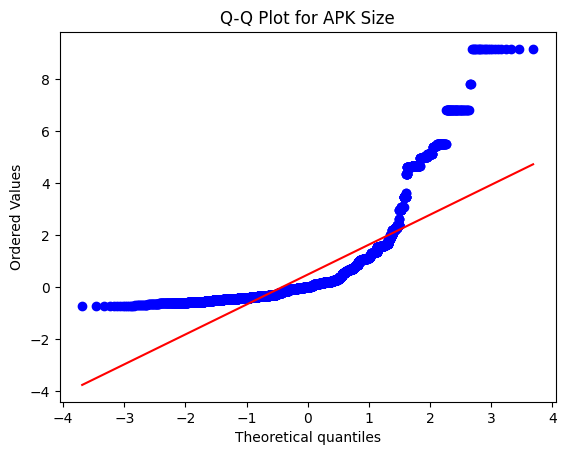

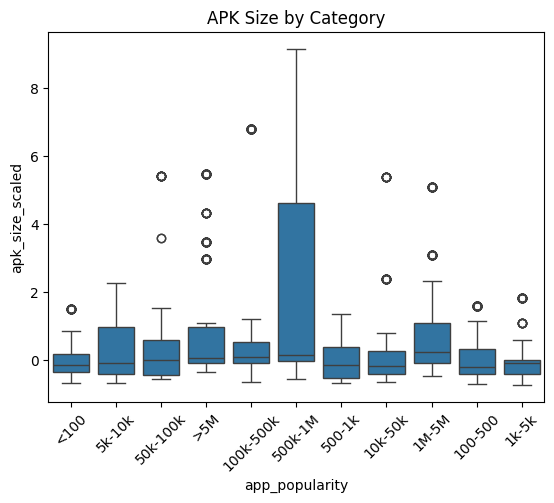

In [138]:
sns.histplot(df["apk_size_scaled"], kde=True)
plt.title("Distribution of APK Size")
plt.xlabel("apk_size")
plt.show()

stats.probplot(df["apk_size_scaled"], dist="norm", plot=plt)
plt.title("Q-Q Plot for APK Size")
plt.show()

sns.boxplot(x="app_popularity", y="apk_size_scaled", data=df)
plt.xticks(rotation=45)
plt.title("APK Size by Category")
plt.show()

In [ ]:
# causal_graph = """
# digraph {
#     is_third_party -> verdict;
#     apk_size_scaled -> is_third_party;
#     apk_size_scaled -> verdict;
#     app_popularity_encoded -> is_third_party;
#     app_popularity_encoded -> verdict;
# }
# """

causal_graph_2 = """
digraph {
    combined -> verdict;
    apk_size_scaled -> combined;
    apk_size_scaled -> verdict;
    app_popularity_encoded -> combined;
    app_popularity_encoded -> verdict;
    app_popularity_encoded -> apk_size_scaled;
}
"""

# causal_graph_only_size = """
# digraph {
#     apk_size_scaled -> is_third_party;
#     apk_size_scaled -> verdict;
#     is_third_party -> verdict;
# }
# """

# causal_graph_only_app_popularity = """
# digraph {
#     is_third_party -> verdict;
#     app_popularity_encoded -> is_third_party;
#     app_popularity_encoded -> verdict;
# }
# """

# causal_graph_after_correlation_test = """
# digraph {
#     is_third_party -> verdict;
#     apk_size_scaled -> is_third_party;
#     app_popularity_encoded -> is_third_party;
#     app_popularity_encoded -> verdict;
#     app_popularity_encoded -> apk_size_scaled;
# }
# """


In [ ]:
# model = CausalModel(
#     data=df,
#     treatment="is_third_party",
#     outcome="verdict",
#     graph=causal_graph.replace("\n", " "),
#     common_causes=["apk_size_scaled", "app_popularity_encoded"],
# )

model_2 = CausalModel(
    data=df,
    treatment="combined",
    outcome="verdict",
    graph=causal_graph_2.replace("\n", " "),
    common_causes=["apk_size_scaled", "app_popularity_encoded"],
)

# model_only_size = CausalModel(
#     data=df,
#     treatment="is_third_party",
#     outcome="verdict",
#     graph=causal_graph_only_size.replace("\n", " "),
#     common_causes=["apk_size_scaled"],
# )

# model_only_app_popularity = CausalModel(
#     data=df,
#     treatment="is_third_party" ,
#     outcome="verdict",
#     graph=causal_graph_only_app_popularity.replace("\n", " "),
#     common_causes=["app_popularity_encoded"],
# )

# model_after_correlation_test = CausalModel(
#     data=df,
#     treatment="is_third_party",
#     outcome="verdict",
#     graph=causal_graph_after_correlation_test.replace("\n", " "),
#     common_causes=["app_popularity_encoded"],
# )


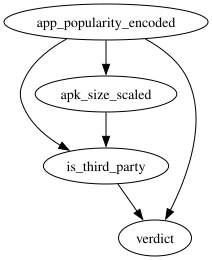

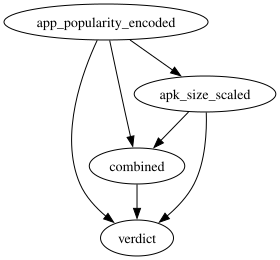

In [ ]:

# g5 = graphviz.Source(causal_graph_after_correlation_test)
g2 = graphviz.Source(causal_graph_2)
# display(g5)
display(g2)

In [ ]:
# identified_estimand = model.identify_effect(proceed_when_unidentifiable=True)
identified_estimand_2 = model_2.identify_effect(proceed_when_unidentifiable=True)
# identified_estimand_only_size = model_only_size.identify_effect(proceed_when_unidentifiable=True)
# identified_estimand_only_app_popularity = model_only_app_popularity.identify_effect(proceed_when_unidentifiable=True)
# identified_estimand_after_correlation_test = model_after_correlation_test.identify_effect(
#     proceed_when_unidentifiable=True
# )

print("\n------- Identified estimands -------")
print(identified_estimand_2)
# print(identified_estimand_after_correlation_test)



------- Identified estimands -------
Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
     d                                                        
───────────(E[verdict|app_popularity_encoded,apk_size_scaled])
d[combined]                                                   
Estimand assumption 1, Unconfoundedness: If U→{combined} and U→verdict then P(verdict|combined,app_popularity_encoded,apk_size_scaled,U) = P(verdict|combined,app_popularity_encoded,apk_size_scaled)

### Estimand : 2
Estimand name: iv
No such variable(s) found!

### Estimand : 3
Estimand name: frontdoor
No such variable(s) found!

### Estimand : 4
Estimand name: general_adjustment
Estimand expression:
     d                                                        
───────────(E[verdict|app_popularity_encoded,apk_size_scaled])
d[combined]                                                   
Estimand assumption 1, Unconfoundedness: If U→{combined} and U→verdict 

In [ ]:
# estimate = model.estimate_effect(
#     identified_estimand,
#     method_name="backdoor.propensity_score_matching",
#     target_units="ate",
#     test_significance=True,
#     confidence_intervals='bootstrap',
#     method_params={
#         "num_simulations": 300,
#         "sample_size_fraction": 1.0,
#         "confidence_level": 0.95,
#     },
# )

estimate_2 = model_2.estimate_effect(
    identified_estimand_2,
    method_name="backdoor.propensity_score_matching",
    target_units="ate",
    test_significance=True,
   confidence_intervals='bootstrap',
    method_params={
        "num_simulations": 300,
        "sample_size_fraction": 1.0,
        "confidence_level": 0.95,
    },
)

# estimate_only_size = model_only_size.estimate_effect(
#     identified_estimand_only_size,
#     method_name="backdoor.propensity_score_matching",
#     target_units="ate",
#     test_significance=True,
#     confidence_intervals='bootstrap',
#     method_params={
#         "num_simulations": 300,
#         "sample_size_fraction": 1.0,
#         "confidence_level": 0.95,
#     },
# )

# estimate_only_app_popularity = model_only_app_popularity.estimate_effect(
#     identified_estimand_only_app_popularity,
#     method_name="backdoor.propensity_score_matching",
#     target_units="ate",
#     test_significance=True,
#     confidence_intervals='bootstrap',
#     method_params={
#         "num_simulations": 300,
#         "sample_size_fraction": 1.0,
#         "confidence_level": 0.95,
#     },
# )

# estimate_after_correlation_test = model_after_correlation_test.estimate_effect(
#     identified_estimand_after_correlation_test,
#     method_name="backdoor.propensity_score_matching",
#     target_units="ate",
#     test_significance=True,
#     confidence_intervals='bootstrap',
#     method_params={
#         "num_simulations": 300,
#         "sample_size_fraction": 1.0,
#         "confidence_level": 0.95,
#     },

# )

print("\n------- Causal effect estimates -------")
# print(estate, "\n", "-------" * 10)
print(estimate_2, "\n", "-------" * 10)
# print(estimate_only_size, "\n", "-------" * 10)
# print(estimate_only_app_popularity, "\n", "-------" * 10)
# print(estimate_after_correlation_test)


------- Causal effect estimates -------
*** Causal Estimate ***

## Identified estimand
Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
     d                                                        
───────────(E[verdict|app_popularity_encoded,apk_size_scaled])
d[combined]                                                   
Estimand assumption 1, Unconfoundedness: If U→{combined} and U→verdict then P(verdict|combined,app_popularity_encoded,apk_size_scaled,U) = P(verdict|combined,app_popularity_encoded,apk_size_scaled)

## Realized estimand
b: verdict~combined+app_popularity_encoded+apk_size_scaled
Target units: ate

## Estimate
Mean value: -0.28482769884043774
p-value: [0, 0.001]
95.0% confidence interval: (np.float64(-0.3973542381185694), np.float64(-0.24252817246447822))
 
 ----------------------------------------------------------------------
*** Causal Estimate ***

## Identified estimand
Estimand type: EstimandType.NONPA

In [ ]:
estimate_2.interpret(method_name="textual_effect_interpreter")

Increasing the treatment variable(s) [is_third_party] from 0 to 1 causes an increase of -0.374979585170668 in the expected value of the outcome [['verdict']], over the data distribution/population represented by the dataset.


In [ ]:
refutation_methods = [
    "random_common_cause",
    "placebo_treatment_refuter",
    "data_subset_refuter",
]

# # print("\n", "----" * 15, "Both size and app_popularity as confounders (graph 1)", "----" * 15)
# for method in refutation_methods:
#     ref = model.refute_estimate(identified_estimand, estimate, method_name=method)
#     # print(f"\nRefuter: {method}\n", ref)

# print("\n", "----" * 15, "Both size and app_popularity as confounders (graph 2)", "----" * 15)
# for method in refutation_methods:
#     ref = model_2.refute_estimate(identified_estimand_2, estimate_2, method_name=method)
#     print(f"\nRefuter: {method}\n", ref)

# # print("\n", "----" * 15, "Only size as confounder", "----" * 15)
# for method in refutation_methods:
#     ref = model_only_size.refute_estimate(identified_estimand_only_size, estimate_only_size, method_name=method)
#     # print(f"\nRefuter: {method}\n", ref)

# # print("\n", "----" * 15, "Only app_popularity as confounder", "----" * 15)
# for method in refutation_methods:
#     ref = model_only_app_popularity.refute_estimate(
#         identified_estimand_only_app_popularity, estimate_only_app_popularity, method_name=method
#     )
#     # print(f"\nRefuter: {method}\n", ref)

print("\n", "----" * 15, "Refutation after correlation test graph", "----" * 15)
for method in refutation_methods:
    if method == "placebo_treatment_refuter":
        ref = model_2.refute_estimate(identified_estimand_2, estimate_2, method_name=method, placebo_type="permute", num_simulations=200)
    elif method == "data_subset_refuter":
        ref = model_2.refute_estimate(identified_estimand_2, estimate_2, method_name=method, subset_fraction=0.8, num_simulations=200)
    else:
        ref = model_2.refute_estimate(identified_estimand_2, estimate_2, method_name=method)

    print(f"\nRefuter: {method}\n", ref)



Refuter: random_common_cause
 Refute: Add a random common cause
Estimated effect:-0.28482769884043774
New effect:-0.2848276988404378
p value:1.0


Refuter: placebo_treatment_refuter
 Refute: Use a Placebo Treatment
Estimated effect:-0.28482769884043774
New effect:-0.0017295443410093093
p value:0.9


Refuter: data_subset_refuter
 Refute: Use a subset of data
Estimated effect:-0.28482769884043774
New effect:-0.25391996733360556
p value:0.5


 ------------------------------------------------------------ Refutation after correlation test graph ------------------------------------------------------------

Refuter: random_common_cause
 Refute: Add a random common cause
Estimated effect:-0.374979585170668
New effect:-0.37497958517066815
p value:1.0


Refuter: placebo_treatment_refuter
 Refute: Use a Placebo Treatment
Estimated effect:-0.374979585170668
New effect:0.009287930752898904
p value:0.78


Refuter: data_subset_refuter
 Refute: Use a subset of data
Estimated effect:-0.374979585170668

## ------------------------ All the correlation tests are added below -----------------------

In [146]:


import numpy as np
import scipy.stats as stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy.stats import mannwhitneyu, kruskal


ALPHA = 0.05


def kruskal_test_continuous_by_groups(df, group_col, continuous_col):
    groups = [g[continuous_col].values for _, g in df.groupby(group_col)]
    H, p = kruskal(*groups)
    print(f"\n{group_col} -> {continuous_col} (Kruskal–Wallis)")
    print(f"H = {H:.3f}, p = {p:.4f}")
    print("Edge supported (p < 0.05)" if p < ALPHA else "Edge NOT supported (p >= 0.05)")
    return H, p


def logistic_regression_numeric_to_binary(df, numeric_col, binary_col):
    X = sm.add_constant(df[numeric_col])
    y = df[binary_col]
    model = sm.Logit(y, X).fit(disp=False)
    p = float(model.pvalues[numeric_col])
    coef = float(model.params[numeric_col])
    print(f"\n{numeric_col} -> {binary_col} (Logistic regression)")
    print(f"coef = {coef:.4f}, p = {p:.4f}")
    print("Edge supported (p < 0.05)" if p < ALPHA else "Edge NOT supported (p >= 0.05)")
    return model


def logistic_regression_binary_to_binary(df, binary_treatment, binary_outcome):
    X = sm.add_constant(df[binary_treatment])
    y = df[binary_outcome]
    model = sm.Logit(y, X).fit(disp=False)
    p = float(model.pvalues[binary_treatment])
    coef = float(model.params[binary_treatment])
    print(f"\n{binary_treatment} -> {binary_outcome} (Logistic regression)")
    print(f"coef = {coef:.4f}, p = {p:.4f}")
    print("Edge supported (p < 0.05)" if p < ALPHA else "Edge NOT supported (p >= 0.05)")
    return model


def chi_square_test_cat_to_binary(df, cat_col, binary_col):
    table = pd.crosstab(df[cat_col], df[binary_col])
    chi2, p, dof, _ = stats.chi2_contingency(table)
    print(f"\n{cat_col} -> {binary_col} (Chi-square)")
    print(f"chi2 = {chi2:.3f}, dof = {dof}, p = {p:.4f}")
    print("Edge supported (p < 0.05)" if p < ALPHA else "Edge NOT supported (p >= 0.05)")
    return chi2, p


def mann_whitney_test(df, numeric_col, binary_col):
    g0 = df[df[binary_col] == 0][numeric_col]
    g1 = df[df[binary_col] == 1][numeric_col]
    U, p = mannwhitneyu(g0, g1, alternative="two-sided")
    print(f"\n{numeric_col} -> {binary_col} (Mann–Whitney U)")
    print(f"U = {U:.3f}, p = {p:.4f}")
    print("Edge supported (p < 0.05)" if p < ALPHA else "Edge NOT supported (p >= 0.05)")
    return U, p



print("\n" + "----"*10 + "Graph Creation Validity: Edge association checks" + "----"*10)

kruskal_test_continuous_by_groups(df, "app_popularity_encoded", "apk_size_scaled")

logistic_regression_numeric_to_binary(df, "app_popularity_encoded", "verdict")
chi_square_test_cat_to_binary(df, "app_popularity_encoded", "verdict")

logistic_regression_numeric_to_binary(df, "app_popularity_encoded", "combined")
chi_square_test_cat_to_binary(df, "app_popularity_encoded", "combined")

logistic_regression_binary_to_binary(df, "combined", "verdict")

logistic_regression_numeric_to_binary(df, "apk_size_scaled", "combined")
mann_whitney_test(df, "apk_size_scaled", "combined")

logistic_regression_numeric_to_binary(df, "apk_size_scaled", "verdict")
mann_whitney_test(df, "apk_size_scaled", "verdict")

mann_whitney_test(df, "app_popularity_encoded", "combined")


from scipy.stats import spearmanr
rho, p = spearmanr(df["apk_size_scaled"], df["app_popularity_encoded"])
print("\napk_size_scaled -> app_popularity_encoded (Spearman)")
print(f"rho = {rho:.4f}, p = {p:.4f}")
print("Edge supported (p < 0.05)" if p < 0.05 else "Edge NOT supported (p >= 0.05)")



----------------------------------------Graph Creation Validity: Edge association checks----------------------------------------

app_popularity_encoded -> apk_size_scaled (Kruskal–Wallis)
H = 648.768, p = 0.0000
Edge supported (p < 0.05)

app_popularity_encoded -> verdict (Logistic regression)
coef = 0.0465, p = 0.0000
Edge supported (p < 0.05)

app_popularity_encoded -> verdict (Chi-square)
chi2 = 75.444, dof = 10, p = 0.0000
Edge supported (p < 0.05)

app_popularity_encoded -> combined (Logistic regression)
coef = 0.0514, p = 0.0002
Edge supported (p < 0.05)

app_popularity_encoded -> combined (Chi-square)
chi2 = 84.537, dof = 10, p = 0.0000
Edge supported (p < 0.05)

combined -> verdict (Logistic regression)
coef = -0.8695, p = 0.0000
Edge supported (p < 0.05)

apk_size_scaled -> combined (Logistic regression)
coef = 0.1510, p = 0.0003
Edge supported (p < 0.05)

apk_size_scaled -> combined (Mann–Whitney U)
U = 1274198.500, p = 0.0000
Edge supported (p < 0.05)

apk_size_scaled -> v